In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
train_images = np.expand_dims(x_train, axis=-1)  # (60000, 28, 28, 1)
test_images  = np.expand_dims(x_test, axis=-1)

model = keras.Sequential([
    keras.layers.InputLayer(input_shape=(1,28,28)),
    keras.layers.Conv2D(32,(2,2),padding='same',activation='relu'),
    keras.layers.MaxPooling2D(padding='same'),
    keras.layers.Conv2D(64,(2,2),padding='same',activation='relu'),
    keras.layers.MaxPooling2D(padding='same'),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(10,input_dim=10, activation='softmax')
])

In [4]:
tf.keras.utils.plot_model(model,expand_nested=True,show_shapes=True,show_layer_names=False)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [5]:
train_images=train_images.astype('float32')/255.0
test_images=test_images.astype('float32')/255.0
train_images = train_images.reshape(train_images.shape[0], 1, 28, 28)
test_images = test_images.reshape(test_images.shape[0], 1, 28, 28)


In [6]:
train_labels_new = tf.keras.utils.to_categorical(y_train,10)
test_labels_new = tf.keras.utils.to_categorical(y_test,10)

In [7]:
model.compile(
    optimizer='RMSprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history=model.fit(
    train_images,train_labels_new,
    batch_size=100,
    epochs=10,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8677 - loss: 0.4389 - val_accuracy: 0.9544 - val_loss: 0.1570
Epoch 2/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9548 - loss: 0.1516 - val_accuracy: 0.9711 - val_loss: 0.0968
Epoch 3/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9675 - loss: 0.1073 - val_accuracy: 0.9718 - val_loss: 0.0940
Epoch 4/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9737 - loss: 0.0836 - val_accuracy: 0.9782 - val_loss: 0.0733
Epoch 5/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9783 - loss: 0.0688 - val_accuracy: 0.9791 - val_loss: 0.0680
Epoch 6/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9810 - loss: 0.0613 - val_accuracy: 0.9806 - val_loss: 0.0668
Epoch 7/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9825 - loss: 0.0545 - val_accuracy: 0.9802 - val_loss: 0.0712
Epoch 8/10
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9842 - loss: 0.0499 - val_accuracy: 0.

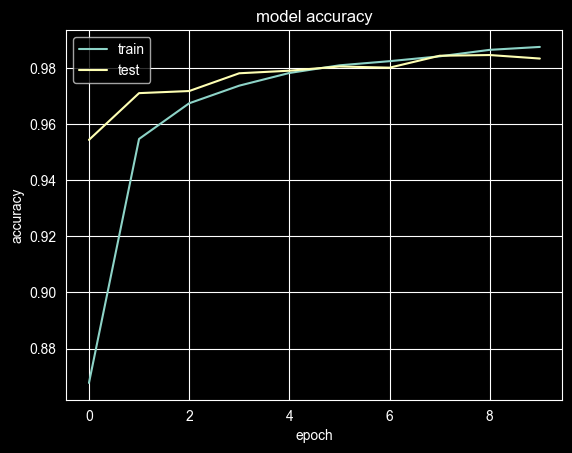

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


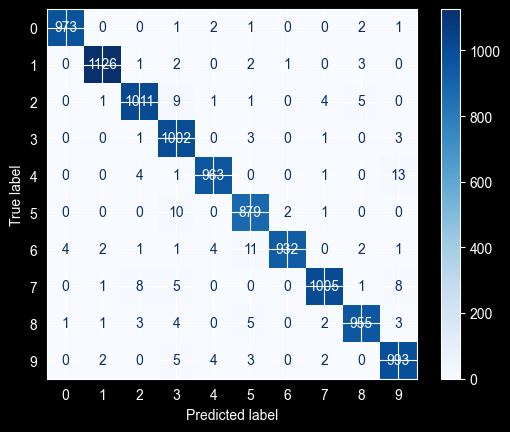

In [10]:
y_pred_probs = model.predict(test_images)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.argmax(test_labels_new,axis=1)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=range(10))
disp.plot(cmap=plt.cm.Blues,values_format='d')
plt.show()

In [11]:
from sklearn.metrics import classification_report
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.96      0.99      0.98      1010
           4       0.99      0.98      0.98       982
           5       0.97      0.99      0.98       892
           6       1.00      0.97      0.98       958
           7       0.99      0.98      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.97      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



### tf/tp для каждого класса

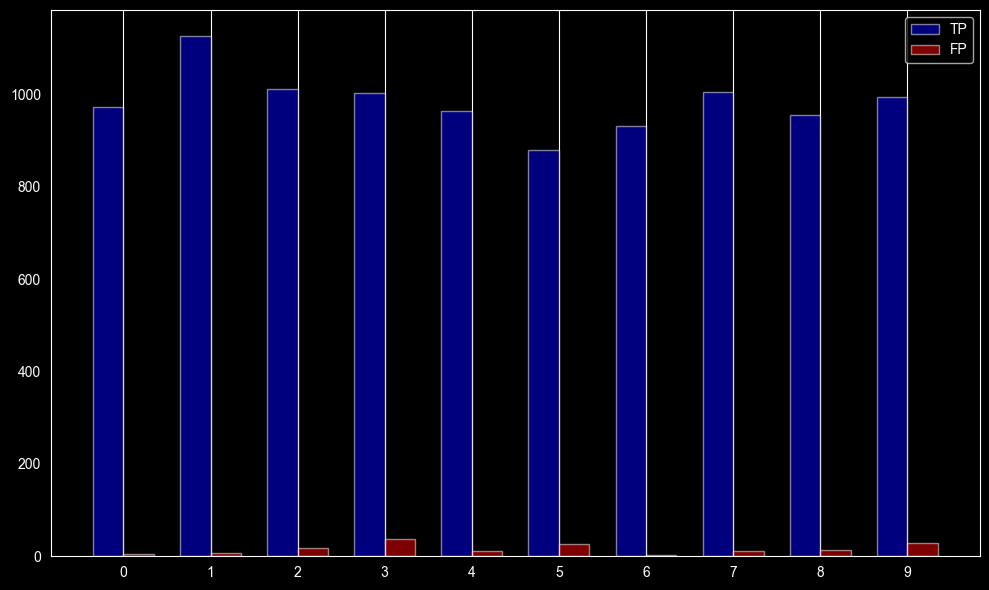

In [12]:
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
classes = np.arange(10)

x = np.arange(len(classes))
width = 0.35

fig,ax = plt.subplots(figsize=(10,6))
bars_tp = ax.bar(x - width/2, TP, width, label='TP',color = 'blue',alpha = 0.5)
bars_fp = ax.bar(x + width/2, FP, width, label='FP', color='red', alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
ax.grid(axis='y')

plt.tight_layout()
plt.show()